In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from pathlib import Path

In [2]:
import random
random.seed(42)
random_state_array = random.sample(range(1, 101), 10)
random_state_array

[82, 15, 4, 95, 36, 32, 29, 18, 14, 87]

lambda_result

In [3]:
lambda_array = [round(0.1+i*0.2, 1) for i in range(5)]
lambda_array

[0.1, 0.3, 0.5, 0.7, 0.9]

In [4]:
expnum = 5
dim = [4+i*5 for i in range(5)]
results = pd.DataFrame(columns=['dim', 'lambda', 'random_state', 'metric1','metric2'])
results

,dim,lambda,random_state,metric1,metric2


In [5]:
expnum = 5
dim = [4+i*5 for i in range(5)]
results_lambda = pd.DataFrame(columns=['dim', 'lambda', 'random_state', 'metric1','metric2'])
for d in dim:
    dim_array = []
    for j in random_state_array:
        for l in lambda_array:
            result_file = r"analysis_outputs/spline_sensitivity_iid_exp{}_dim{}_seed{}/lambda/rseto_ipa_lambda{}_metric1.npy".format(expnum, d, j, l)
            result_1 = np.load(result_file)
            result_file = r"analysis_outputs/spline_sensitivity_iid_exp{}_dim{}_seed{}/lambda/rseto_ipa_lambda{}_metric2.npy".format(expnum, d, j, l)
            result_2 = np.load(result_file)
            data = pd.DataFrame({'dim': d, 'lambda': l, 'random_state': j, 'metric1': result_1, 'metric2': result_2}, index=[0])
            results_lambda = pd.concat([results_lambda, data], ignore_index=True)
results_qfr = pd.DataFrame(columns=['dim','random_state', 'metric1','metric2'])
for d in dim:
    dim_array = []
    for j in random_state_array:
        result_file = r"analysis_outputs/spline_sensitivity_iid_exp{}_dim{}_seed{}/lambda/spline_qfr_metric1.npy".format(expnum, d, j, l)
        result_1 = np.load(result_file)
        result_file = r"analysis_outputs/spline_sensitivity_iid_exp{}_dim{}_seed{}/lambda/spline_qfr_metric2.npy".format(expnum, d, j, l)
        result_2 = np.load(result_file)
        data = pd.DataFrame({'dim': d,'random_state': j, 'metric1': result_1, 'metric2': result_2}, index=[0])
        results_qfr = pd.concat([results_qfr, data], ignore_index=True)
gendfl_spline = pd.DataFrame(columns=['dim', 'random_state', 'metric1','metric2'])
for d in dim:
    for j in random_state_array:
        result_file = r"analysis_outputs/spline_sensitivity_iid_exp{}_dim{}_seed{}/lambda/gendfl_spline_metric1.npy".format(expnum, d, j, l)
        result_1 = np.load(result_file)
        result_file = r"analysis_outputs/spline_sensitivity_iid_exp{}_dim{}_seed{}/lambda/gendfl_spline_metric2.npy".format(expnum, d, j, l)
        result_2 = np.load(result_file)
        data = pd.DataFrame({'dim': d, 'random_state': j, 'metric1': result_1, 'metric2': result_2}, index=[0])
        gendfl_spline = pd.concat([gendfl_spline, data], ignore_index=True)
gendfl_spline

FileNotFoundError: [Errno 2] No such file or directory: 'analysis_outputs/spline_sensitivity_iid_exp5_dim4_seed82/lambda/rseto_ipa_lambda0.1_metric1.npy'

In [ ]:
results_lambda.to_excel(r'syn_lambda_ipa.xlsx', index=False)
gendfl_spline.to_excel(r'syn_gendfl_spline.xlsx', index=False)
results_qfr.to_excel(r'syn_spline_qfr.xlsx', index=False)

In [ ]:
expnum = 5
dim = [4+i*5 for i in range(5)]
results_m = pd.DataFrame(columns=['dim', 'm', 'random_state', 'metric1','metric2'])
m_array = [8*(4**i) for i in range(5)]
for d in dim:
    dim_array = []
    for j in random_state_array:
        for m in m_array:
            result_file = r"analysis_outputs/spline_sensitivity_iid_exp{}_dim{}_seed{}/m/rseto_ipa_m{}_metric1.npy".format(expnum, d, j, m)
            result_1 = np.load(result_file)
            result_file = r"analysis_outputs/spline_sensitivity_iid_exp{}_dim{}_seed{}/m/rseto_ipa_m{}_metric2.npy".format(expnum, d, j, m)
            result_2 = np.load(result_file)
            data = pd.DataFrame({'dim': d, 'm': m, 'random_state': j, 'metric1': result_1, 'metric2': result_2}, index=[0])
            results_m = pd.concat([results_m, data], ignore_index=True)
results_m.to_excel(r'syn_m_ipa.xlsx', index=False)

/var/folders/c1/nn1rtg8915lb_x0l9qqmyytr0000gn/T/ipykernel_5495/1704627960.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_m = pd.concat([results_m, data], ignore_index=True)


In [ ]:
expnum = 5
dim = [4+i*5 for i in range(5)]
simulation_num_array = [(4**i) for i in range(5)]
simulation_num_records = []
for d in dim:
    for j in random_state_array:
        for simulation_num in simulation_num_array:
            result_root = Path(r"analysis_outputs/spline_sensitivity_iid_exp{}_dim{}_seed{}/simulation_num".format(expnum, d, j))
            method = 'rseto_ipa_R{}'.format(simulation_num)
            simulation_num_records.append({
                'dim': d,
                'simulation_num': simulation_num,
                'random_state': j,
                'metric1': float(np.load(result_root / '{}_metric1.npy'.format(method)).reshape(-1)[0]),
                'metric2': float(np.load(result_root / '{}_metric2.npy'.format(method)).reshape(-1)[0]),
                'ipa_batched_gradient_variance': float(np.load(result_root / '{}_ipa_batched_gradient_variance.npy'.format(method)).reshape(-1)[0]),
                'weighted_ipa_batched_gradient_variance': float(np.load(result_root / '{}_weighted_ipa_batched_gradient_variance.npy'.format(method)).reshape(-1)[0]),
            })
results_simulation_num = pd.DataFrame.from_records(simulation_num_records)
results_simulation_num.to_excel(r'syn_simulation_num_ipa.xlsx', index=False)

/var/folders/c1/nn1rtg8915lb_x0l9qqmyytr0000gn/T/ipykernel_5495/1106473491.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_simulation_num = pd.concat([results_simulation_num, data], ignore_index=True)


In [ ]:
results_simulation_num

,dim,simulation_num,random_state,metric1,metric2
0,4,1,82,57.533947,65.856110
1,4,4,82,57.525784,65.850754
2,4,16,82,57.515804,65.840157
3,4,64,82,57.514256,65.841743
4,4,256,82,57.495316,65.823914
...,...,...,...,...,...
245,24,1,87,1032.237427,663.980896
246,24,4,87,1032.987305,650.888428
247,24,16,87,1032.286987,665.524353
248,24,64,87,1032.363525,665.564636


In [ ]:
m_array = [(4**i) for i in range(5)]
m_array

[1, 4, 16, 64, 256]

In [ ]:
results_lambda[(results_lambda['dim']==4) & (results_lambda['lambda']==0.1)]['metric1'].mean()

np.float64(190.48738327026368)

## Unified hyperparameter and ETE analysis

This section reads the corrected fixed-DGP results for the $\lambda$, $M$, and simulation-count $R$ sweeps, together with GenDFL, Spline QFR, ERM, LightGBM, and the neural end-to-end benchmark. Metric 2 follows each saved experiment protocol: spline models recompute the exact conditional quantile for every cost pair, while point-prediction ETE models reuse their single trained decision across cost pairs.

In [6]:
from pathlib import Path
import re
from IPython.display import display

ANALYSIS_ROOT = Path("analysis_outputs")
ETE_DETAIL_PATH = Path("analysis_outputs_ete/fixed_dgp_exp5_traditional_50epochs_projected_sgd/fixed_dgp_results_detail.csv")
SUMMARY_OUTPUT = ANALYSIS_ROOT / "read_syn_summary"
SUMMARY_OUTPUT.mkdir(parents=True, exist_ok=True)

DIMS = [4, 9, 14, 19, 24]
SEEDS = [82, 15, 4, 95, 36, 32, 29, 18, 14, 87]
SWEEP_INFO = {
    "lambda": {"symbol": r"$\lambda$", "values": [0.1, 0.3, 0.5, 0.7, 0.9]},
    "m": {"symbol": r"$M$", "values": [8, 32, 128, 512, 2048]},
    "simulation_num": {"symbol": r"$R$", "values": [1, 4, 16, 64, 256]},
}
METHOD_LABELS = {
    "gendfl_spline": "GenDFL",
    "spline_qfr": "Spline QFR",
    "erm": "ERM",
    "lightgbm": "LightGBM",
    "end_to_end": "Benchmark",
}
ROOT_PATTERN = re.compile(r"spline_sensitivity_iid_exp5_dim(\d+)_seed(\d+)")

def load_sensitivity_results(root=ANALYSIS_ROOT):
    sweep_frames = []
    baseline_frames = []
    for experiment_dir in sorted(root.glob("spline_sensitivity_iid_exp5_dim*_seed*")):
        match = ROOT_PATTERN.fullmatch(experiment_dir.name)
        if match is None:
            continue
        dim_value, seed = map(int, match.groups())
        for sweep_name in SWEEP_INFO:
            detail_path = experiment_dir / sweep_name / "detail.csv"
            if not detail_path.exists():
                raise FileNotFoundError(detail_path)
            frame = pd.read_csv(detail_path)
            frame["dim"] = dim_value
            frame["random_state"] = seed
            rseto = frame[frame["method"].str.startswith("rseto_ipa_")].copy()
            rseto["sweep"] = sweep_name
            rseto["parameter"] = pd.to_numeric(rseto["sweep_value"])
            rseto["model"] = "RSETO-IPA"
            sweep_frames.append(rseto[["dim", "random_state", "sweep", "parameter", "model", "metric1", "metric2"]])
            if sweep_name == "lambda":
                baseline = frame[frame["method"].isin(["gendfl_spline", "spline_qfr"])].copy()
                baseline["model"] = baseline["method"].map(METHOD_LABELS)
                baseline_frames.append(baseline[["dim", "random_state", "model", "metric1", "metric2"]])
    return (
        pd.concat(sweep_frames, ignore_index=True),
        pd.concat(baseline_frames, ignore_index=True),
    )

sensitivity_results, spline_reference_results = load_sensitivity_results()
ete_results = pd.read_csv(ETE_DETAIL_PATH)
if ete_results["error"].notna().any():
    raise RuntimeError(ete_results.loc[ete_results["error"].notna(), ["dim", "random_state", "model", "error"]])
ete_results["model"] = ete_results["model"].map(METHOD_LABELS)
ete_results = ete_results[["dim", "random_state", "model", "metric1", "metric2"]].copy()
reference_results = pd.concat([spline_reference_results, ete_results], ignore_index=True)


ValueError: No objects to concatenate

In [ ]:
expected_sweep_rows = len(DIMS) * len(SEEDS) * sum(len(info["values"]) for info in SWEEP_INFO.values())
expected_reference_rows = len(DIMS) * len(SEEDS) * len(METHOD_LABELS)
assert len(sensitivity_results) == expected_sweep_rows, (len(sensitivity_results), expected_sweep_rows)
assert len(reference_results) == expected_reference_rows, (len(reference_results), expected_reference_rows)
assert set(sensitivity_results["dim"]) == set(DIMS)
assert set(sensitivity_results["random_state"]) == set(SEEDS)
assert sensitivity_results[["metric1", "metric2"]].notna().all().all()
assert reference_results[["metric1", "metric2"]].notna().all().all()

coverage = (
    sensitivity_results.groupby(["sweep", "dim", "parameter"])
    .size()
    .rename("runs")
    .reset_index()
    .sort_values(["sweep", "dim", "parameter"])
)
print(f"Loaded {len(sensitivity_results)} RSETO-IPA sweep rows and {len(reference_results)} reference-model rows.")
display(coverage.groupby("sweep")["runs"].agg(["min", "max"]))
display(reference_results.groupby(["dim", "model"]).size().unstack("model"))


Loaded 750 RSETO-IPA sweep rows and 250 reference-model rows.


,min,max
sweep,,
lambda,10,10
m,10,10
simulation_num,10,10


model,Benchmark,ERM,GenDFL,LightGBM,Spline QFR
dim,,,,,
4,10,10,10,10,10
9,10,10,10,10,10
14,10,10,10,10,10
19,10,10,10,10,10
24,10,10,10,10,10


### Mean results and LaTeX rows

Each entry is the mean over the ten random seeds. The smallest mean in each dimension is bolded, without appending standard deviations.

In [ ]:
REFERENCE_ORDER = ["GenDFL", "Spline QFR", "ERM", "LightGBM", "Benchmark"]

def parameter_column_name(sweep, value):
    if sweep == "lambda":
        return f"Lambda {float(value):.1f}"
    if sweep == "m":
        return f"M {int(value)}"
    return f"R {int(value)}"

def build_mean_table(sweep, metric):
    values = SWEEP_INFO[sweep]["values"]
    selected = sensitivity_results[sensitivity_results["sweep"] == sweep]
    sweep_mean = selected.pivot_table(index="dim", columns="parameter", values=metric, aggfunc="mean")
    sweep_mean = sweep_mean.reindex(index=DIMS, columns=values)
    sweep_mean.columns = [parameter_column_name(sweep, value) for value in values]
    reference_mean = reference_results.pivot_table(index="dim", columns="model", values=metric, aggfunc="mean")
    reference_mean = reference_mean.reindex(index=DIMS, columns=REFERENCE_ORDER)
    return pd.concat([sweep_mean, reference_mean], axis=1).reset_index().rename(columns={"dim": "Dim"})

def print_latex_rows(table):
    for _, row in table.iterrows():
        numeric = pd.to_numeric(row.drop(labels="Dim"), errors="coerce")
        minimum = numeric.min()
        cells = [str(int(row["Dim"]))]
        for column in table.columns[1:]:
            value = float(row[column])
            formatted = f"{value:.2f}"
            if np.isclose(value, minimum, rtol=1e-10, atol=1e-10):
                formatted = rf"\textbf{{{formatted}}}"
            cells.append(formatted)
        print(" & ".join(cells) + " " + chr(92) * 2)

mean_tables = {}
with pd.ExcelWriter(SUMMARY_OUTPUT / "synthetic_hyperparameter_mean_tables.xlsx") as writer:
    for sweep_name in SWEEP_INFO:
        for metric_name in ["metric1", "metric2"]:
            table = build_mean_table(sweep_name, metric_name)
            mean_tables[(sweep_name, metric_name)] = table
            table.to_excel(writer, sheet_name=f"{sweep_name}_{metric_name}"[:31], index=False)
            print(f"\n{sweep_name} - {metric_name}")
            display(table.style.format({column: "{:.2f}" for column in table.columns if column != "Dim"}))
            print_latex_rows(table)



lambda - metric1


,Dim,Lambda 0.1,Lambda 0.3,Lambda 0.5,Lambda 0.7,Lambda 0.9,GenDFL,Spline QFR,ERM,LightGBM,Benchmark
0,4,190.49,190.51,190.47,190.55,190.70,190.78,201.54,189.73,190.52,190.63
1,9,260.23,260.40,260.37,260.10,260.38,260.45,279.71,258.37,259.18,259.52
2,14,380.70,380.37,380.30,380.38,380.81,382.37,398.91,378.20,380.47,380.05
3,19,358.63,358.25,358.36,358.69,359.04,364.24,393.89,354.88,357.44,358.06
4,24,327.28,327.09,326.74,326.75,326.57,327.94,354.28,323.68,325.58,326.31


4 & 190.49 & 190.51 & 190.47 & 190.55 & 190.70 & 190.78 & 201.54 & \textbf{189.73} & 190.52 & 190.63 \\
9 & 260.23 & 260.40 & 260.37 & 260.10 & 260.38 & 260.45 & 279.71 & \textbf{258.37} & 259.18 & 259.52 \\
14 & 380.70 & 380.37 & 380.30 & 380.38 & 380.81 & 382.37 & 398.91 & \textbf{378.20} & 380.47 & 380.05 \\
19 & 358.63 & 358.25 & 358.36 & 358.69 & 359.04 & 364.24 & 393.89 & \textbf{354.88} & 357.44 & 358.06 \\
24 & 327.28 & 327.09 & 326.74 & 326.75 & 326.57 & 327.94 & 354.28 & \textbf{323.68} & 325.58 & 326.31 \\

lambda - metric2


,Dim,Lambda 0.1,Lambda 0.3,Lambda 0.5,Lambda 0.7,Lambda 0.9,GenDFL,Spline QFR,ERM,LightGBM,Benchmark
0,4,220.17,210.02,206.41,205.67,205.40,205.37,217.23,313.57,314.24,314.02
1,9,298.82,279.10,272.87,271.39,271.18,271.16,287.57,383.61,387.32,385.86
2,14,351.94,336.71,333.93,333.18,333.48,332.76,345.71,475.18,474.85,477.49
3,19,428.60,407.89,397.18,393.95,393.27,392.77,414.92,610.47,600.78,610.93
4,24,351.57,339.59,335.91,332.25,331.42,331.62,357.41,461.79,461.25,452.91


4 & 220.17 & 210.02 & 206.41 & 205.67 & 205.40 & \textbf{205.37} & 217.23 & 313.57 & 314.24 & 314.02 \\
9 & 298.82 & 279.10 & 272.87 & 271.39 & 271.18 & \textbf{271.16} & 287.57 & 383.61 & 387.32 & 385.86 \\
14 & 351.94 & 336.71 & 333.93 & 333.18 & 333.48 & \textbf{332.76} & 345.71 & 475.18 & 474.85 & 477.49 \\
19 & 428.60 & 407.89 & 397.18 & 393.95 & 393.27 & \textbf{392.77} & 414.92 & 610.47 & 600.78 & 610.93 \\
24 & 351.57 & 339.59 & 335.91 & 332.25 & \textbf{331.42} & 331.62 & 357.41 & 461.79 & 461.25 & 452.91 \\

m - metric1


...

4 & 208.80 & 207.01 & 206.41 & 206.33 & 206.43 & \textbf{205.37} & 217.23 & 313.57 & 314.24 & 314.02 \\
9 & 276.02 & 272.94 & 272.87 & 272.85 & 273.29 & \textbf{271.16} & 287.57 & 383.61 & 387.32 & 385.86 \\
14 & 341.32 & 336.30 & 333.93 & 333.52 & 333.87 & \textbf{332.76} & 345.71 & 475.18 & 474.85 & 477.49 \\
19 & 405.71 & 397.84 & 397.18 & 397.02 & 396.87 & \textbf{392.77} & 414.92 & 610.47 & 600.78 & 610.93 \\
24 & 335.40 & 335.28 & 335.91 & 333.93 & 334.13 & \textbf{331.62} & 357.41 & 461.79 & 461.25 & 452.91 \\

simulation_num - metric1


,Dim,R 1,R 4,R 16,R 64,R 256,GenDFL,Spline QFR,ERM,LightGBM,Benchmark
0,4,190.53,190.55,190.47,190.52,190.48,190.78,201.54,189.73,190.52,190.63
1,9,260.39,260.29,260.37,260.34,260.29,260.45,279.71,258.37,259.18,259.52
2,14,380.24,380.29,380.30,380.25,380.25,382.37,398.91,378.20,380.47,380.05
3,19,358.48,358.52,358.36,358.38,358.49,364.24,393.89,354.88,357.44,358.06
4,24,326.71,326.91,326.74,326.69,326.79,327.94,354.28,323.68,325.58,326.31


4 & 190.53 & 190.55 & 190.47 & 190.52 & 190.48 & 190.78 & 201.54 & \textbf{189.73} & 190.52 & 190.63 \\
9 & 260.39 & 260.29 & 260.37 & 260.34 & 260.29 & 260.45 & 279.71 & \textbf{258.37} & 259.18 & 259.52 \\
14 & 380.24 & 380.29 & 380.30 & 380.25 & 380.25 & 382.37 & 398.91 & \textbf{378.20} & 380.47 & 380.05 \\
19 & 358.48 & 358.52 & 358.36 & 358.38 & 358.49 & 364.24 & 393.89 & \textbf{354.88} & 357.44 & 358.06 \\
24 & 326.71 & 326.91 & 326.74 & 326.69 & 326.79 & 327.94 & 354.28 & \textbf{323.68} & 325.58 & 326.31 \\

simulation_num - metric2


,Dim,R 1,R 4,R 16,R 64,R 256,GenDFL,Spline QFR,ERM,LightGBM,Benchmark
0,4,206.60,206.54,206.41,206.39,206.62,205.37,217.23,313.57,314.24,314.02
1,9,272.86,272.70,272.87,273.29,272.41,271.16,287.57,383.61,387.32,385.86
2,14,334.03,334.12,333.93,333.77,333.87,332.76,345.71,475.18,474.85,477.49
3,19,397.77,396.99,397.18,396.60,397.88,392.77,414.92,610.47,600.78,610.93
4,24,335.04,334.67,335.91,336.06,336.14,331.62,357.41,461.79,461.25,452.91


4 & 206.60 & 206.54 & 206.41 & 206.39 & 206.62 & \textbf{205.37} & 217.23 & 313.57 & 314.24 & 314.02 \\
9 & 272.86 & 272.70 & 272.87 & 273.29 & 272.41 & \textbf{271.16} & 287.57 & 383.61 & 387.32 & 385.86 \\
14 & 334.03 & 334.12 & 333.93 & 333.77 & 333.87 & \textbf{332.76} & 345.71 & 475.18 & 474.85 & 477.49 \\
19 & 397.77 & 396.99 & 397.18 & 396.60 & 397.88 & \textbf{392.77} & 414.92 & 610.47 & 600.78 & 610.93 \\
24 & 335.04 & 334.67 & 335.91 & 336.06 & 336.14 & \textbf{331.62} & 357.41 & 461.79 & 461.25 & 452.91 \\


### Metric 1 and Metric 2 confidence trends

Following `read_data_sample.ipynb`, every curve contains only RSETO-IPA results: the line is the ten-seed mean and the shaded region is the $1.96\,\mathrm{SE}$ confidence band. The horizontal axis is feature dimension, and colors distinguish the tested hyperparameter values. Exactly three figures are produced (one per sweep), with Metric 1 and Metric 2 shown side by side.

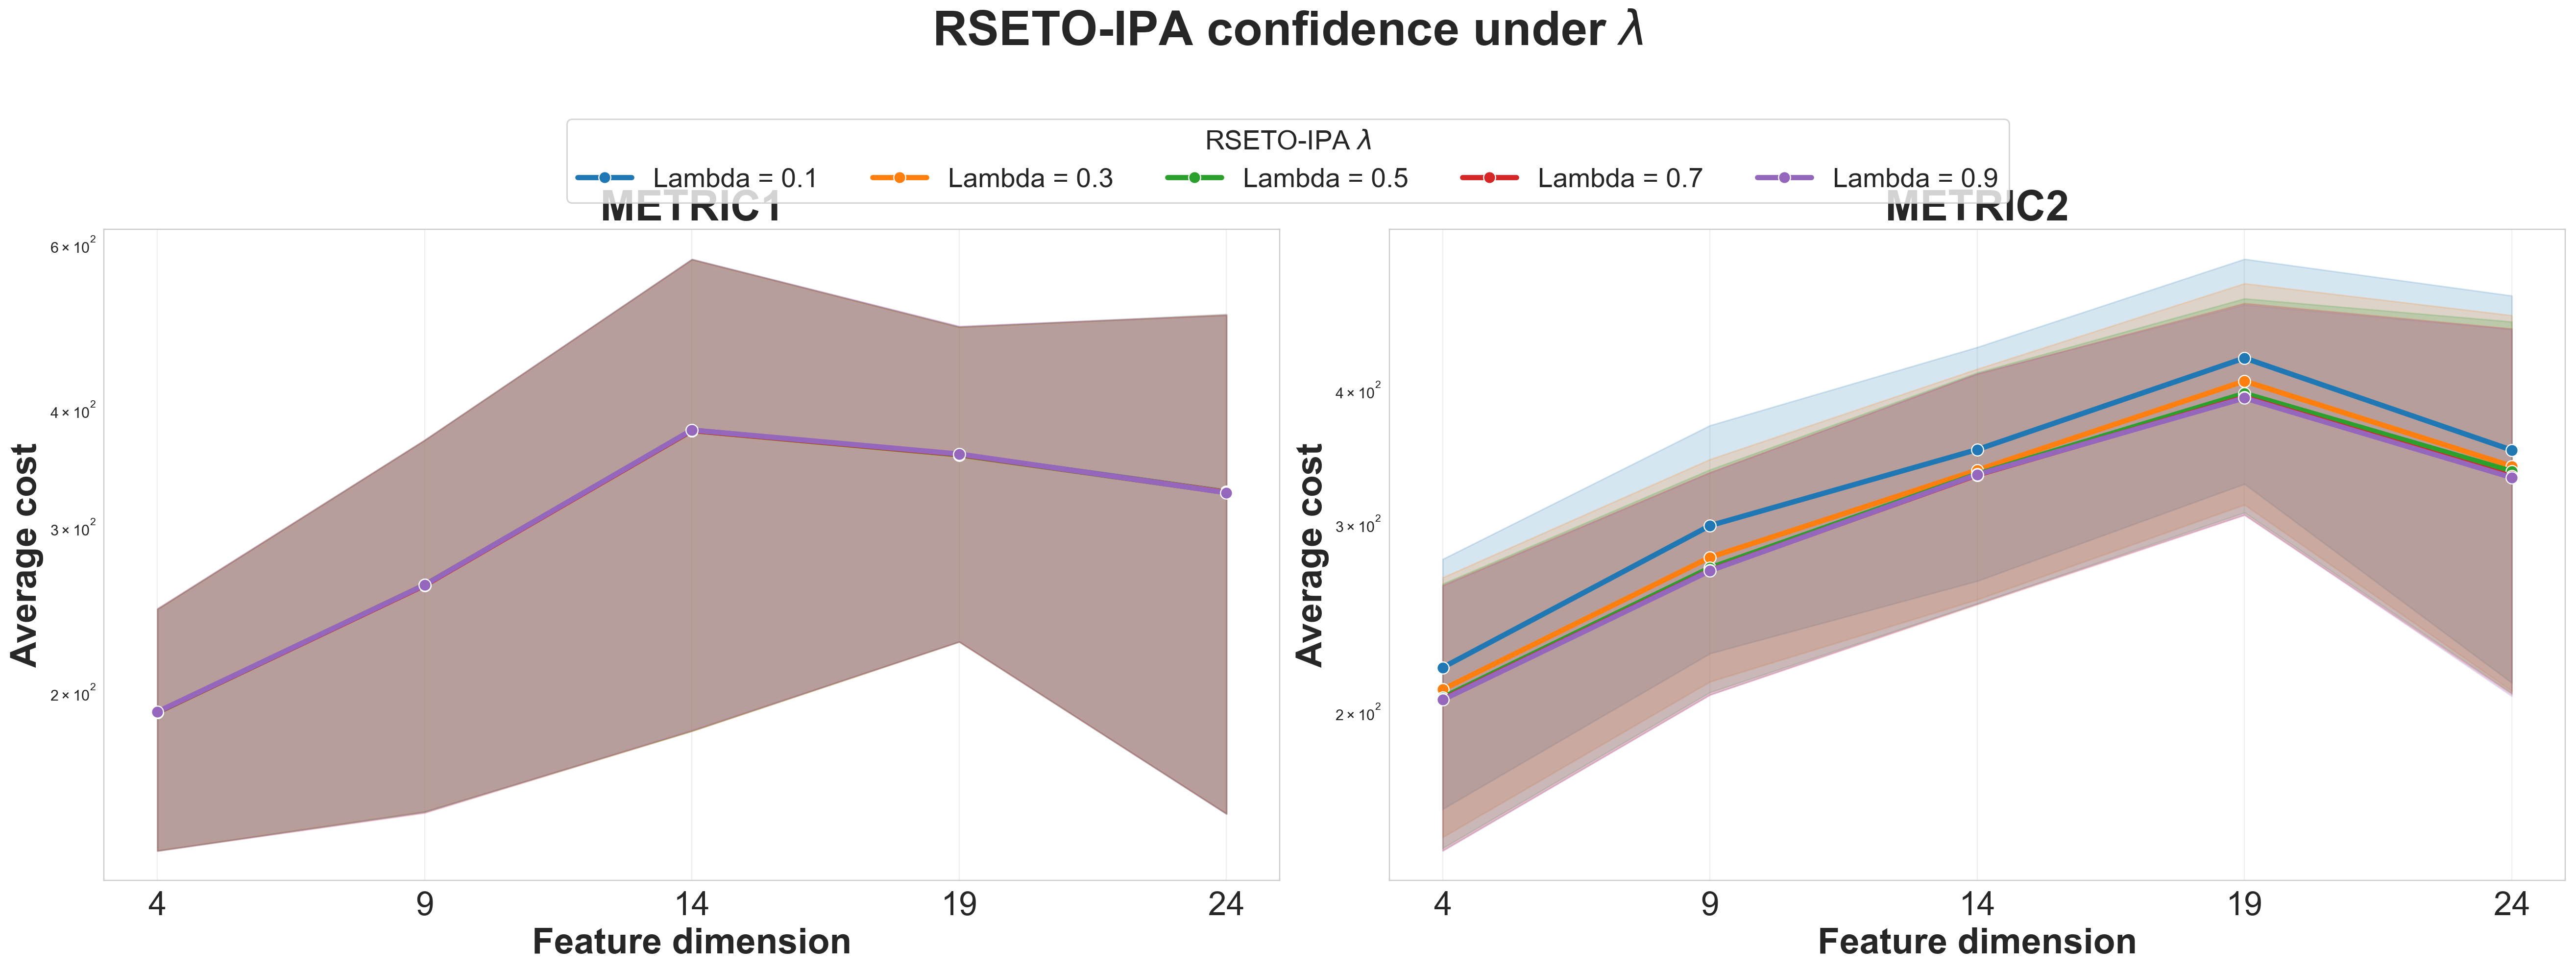

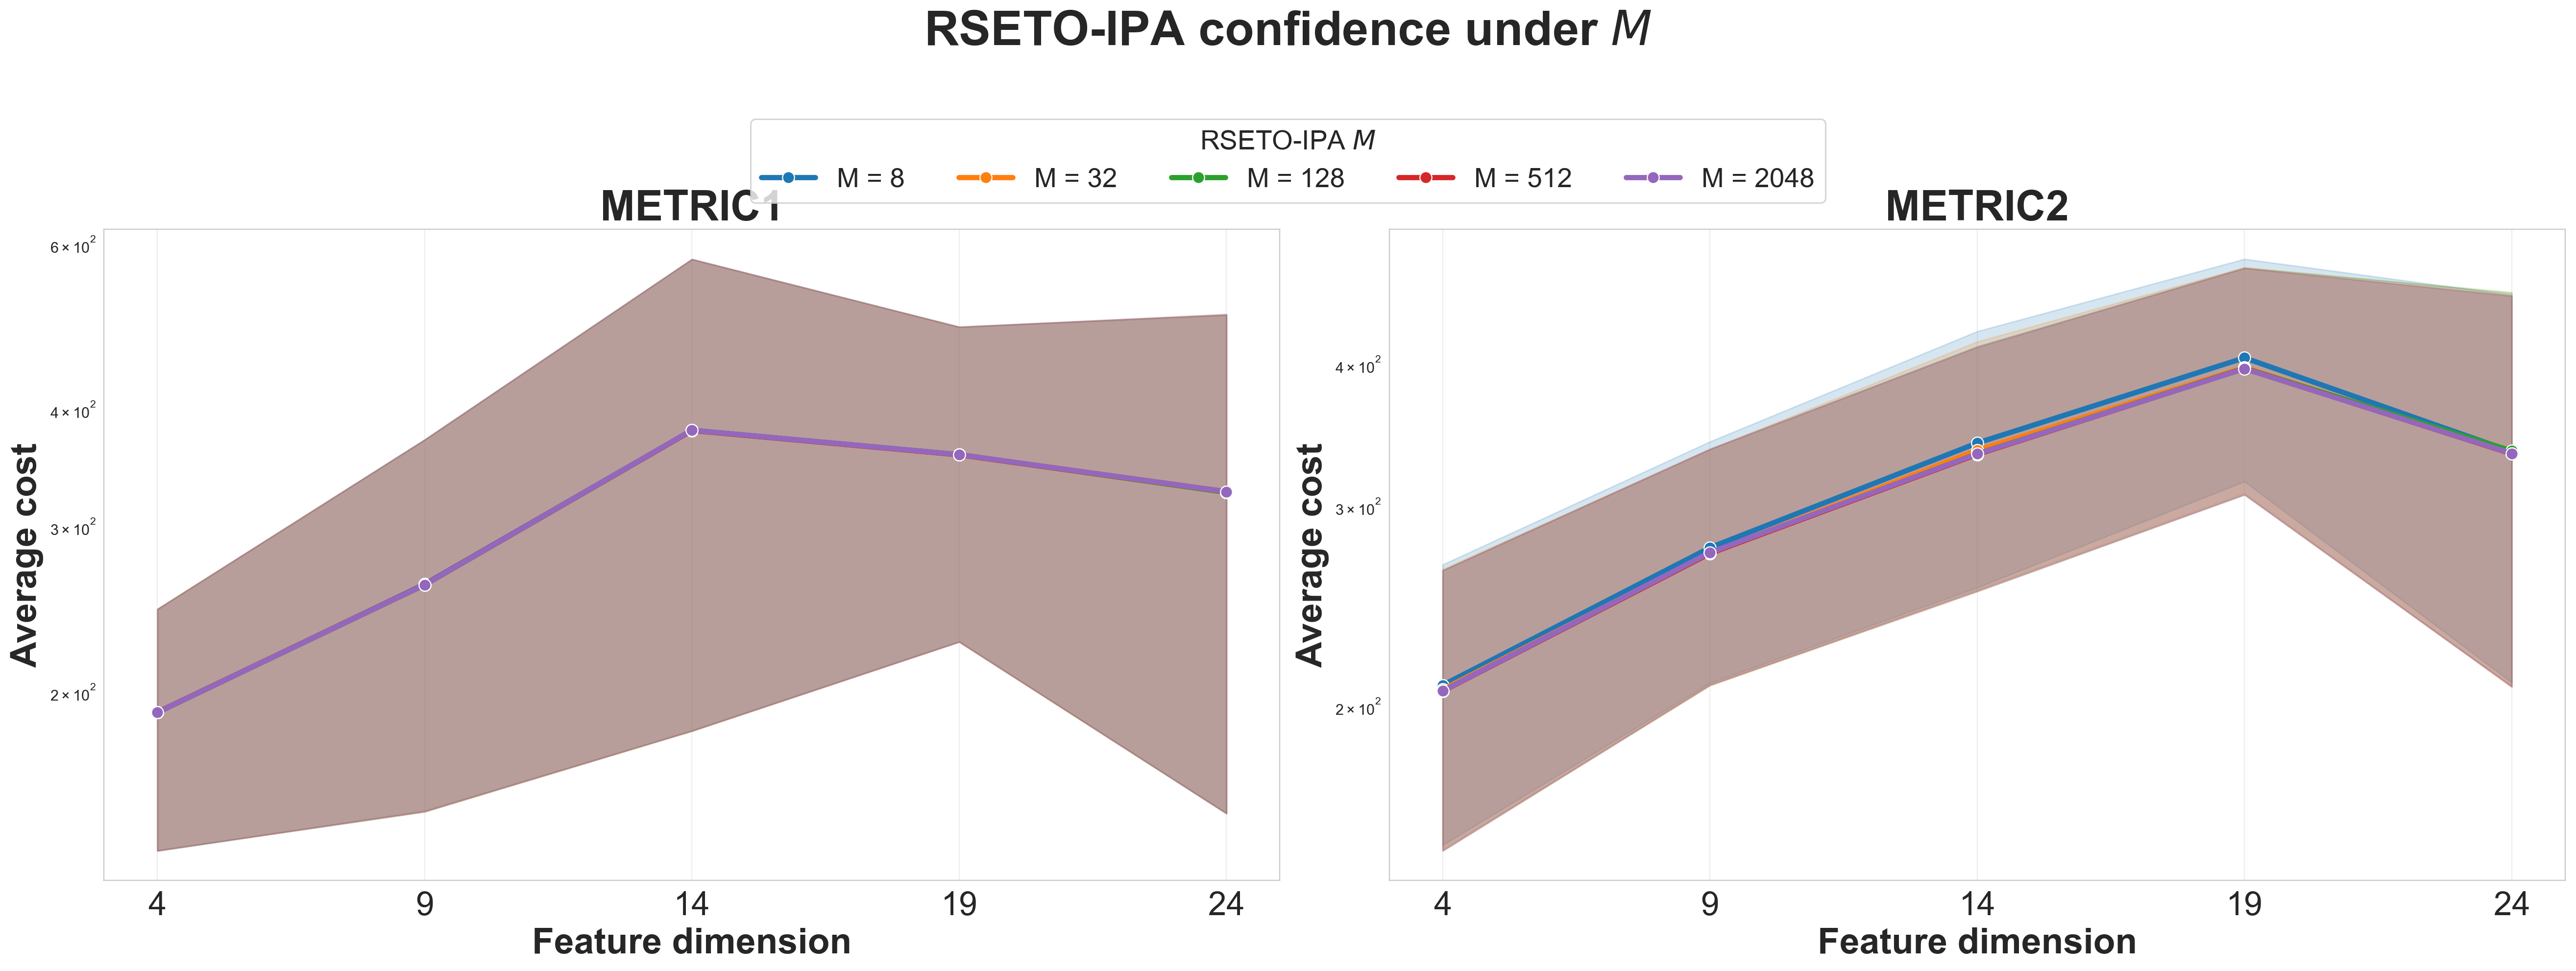

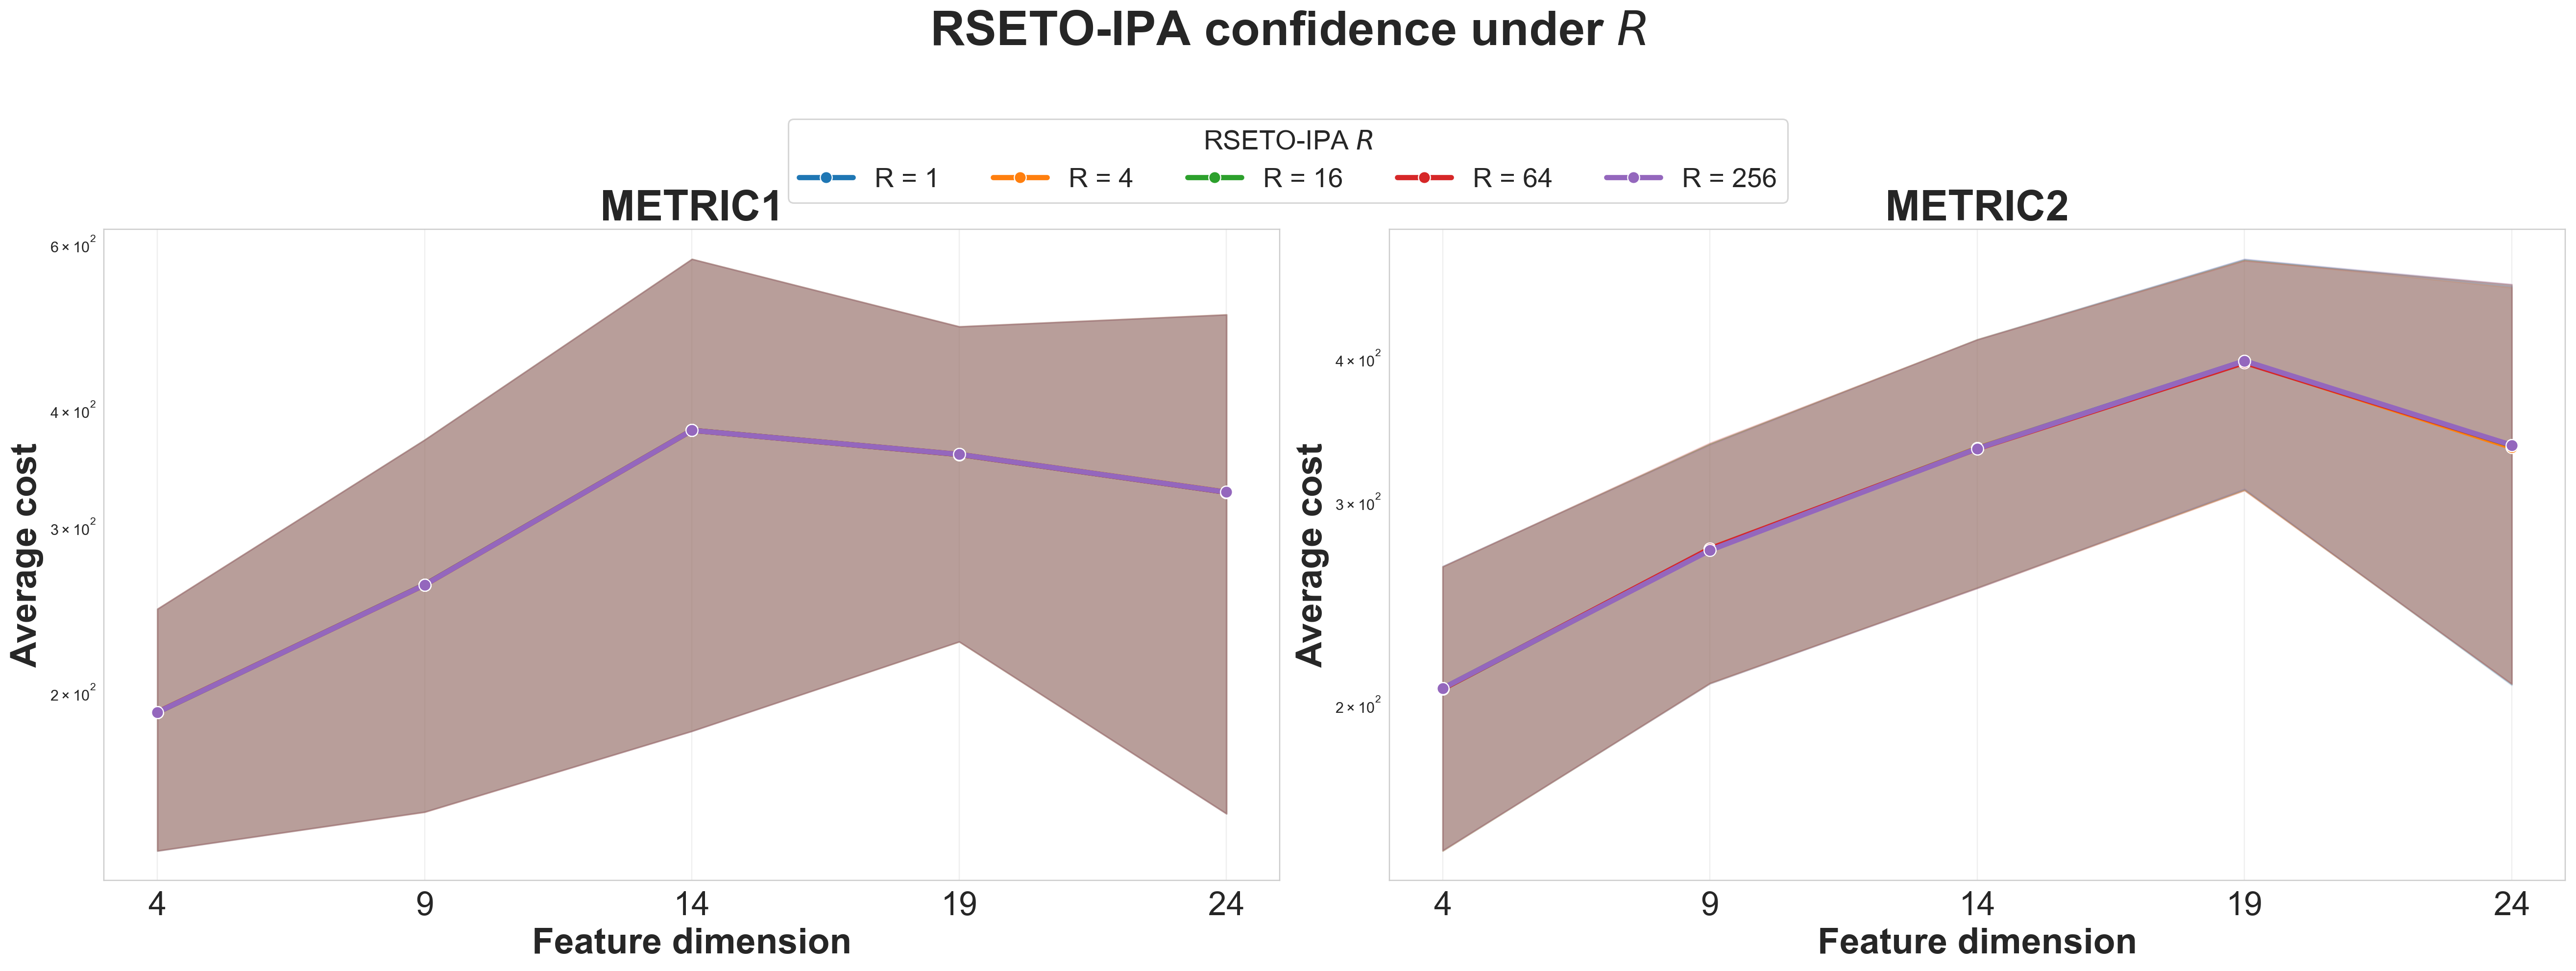

In [ ]:
def confidence_stats(frame, group_column, metric):
    stats = (
        frame.groupby(group_column)[metric]
        .agg(mean="mean", std=lambda values: values.std(ddof=0), count="count")
        .reset_index()
        .sort_values(group_column)
    )
    stats["ci95"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    stats["lower"] = stats["mean"] - stats["ci95"]
    stats["upper"] = stats["mean"] + stats["ci95"]
    return stats

def plot_rseto_parameter_confidence(sweep, save=True):
    selected = sensitivity_results[sensitivity_results["sweep"] == sweep]
    parameter_values = SWEEP_INFO[sweep]["values"]
    symbol = SWEEP_INFO[sweep]["symbol"]

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(24, 8), dpi=220)
    colors = sns.color_palette("tab10", n_colors=len(parameter_values))
    for axis, metric in zip(axes, ["metric1", "metric2"]):
        for color, parameter_value in zip(colors, parameter_values):
            current = selected[np.isclose(selected["parameter"], parameter_value)]
            stats = confidence_stats(current, "dim", metric)
            x = stats["dim"].to_numpy(dtype=float)
            mean = stats["mean"].to_numpy(dtype=float)
            lower = stats["lower"].to_numpy(dtype=float)
            upper = stats["upper"].to_numpy(dtype=float)
            parameter_label = parameter_column_name(sweep, parameter_value).replace(" ", " = ")
            sns.lineplot(x=x, y=mean, ax=axis, color=color, linewidth=3.5, marker="o", markersize=8, label=parameter_label)
            axis.fill_between(x, lower, upper, color=color, alpha=0.18)
        axis.set_yscale("log")
        axis.set_xticks(DIMS)
        axis.set_xticklabels([str(value) for value in DIMS])
        axis.set_xlabel("Feature dimension", fontsize=24, fontweight="bold")
        axis.set_ylabel("Average cost", fontsize=24, fontweight="bold")
        axis.set_title(metric.upper(), fontsize=28, fontweight="bold")
        axis.tick_params(axis="both", labelsize=22)
        axis.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    for axis in axes:
        legend = axis.get_legend()
        if legend is not None:
            legend.remove()
    fig.legend(handles, labels, title=f"RSETO-IPA {symbol}", fontsize=18, title_fontsize=18, loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=len(parameter_values), frameon=True)
    fig.suptitle(f"RSETO-IPA confidence under {symbol}", fontsize=32, fontweight="bold", y=1.12)
    fig.tight_layout()
    if save:
        output_stem = SUMMARY_OUTPUT / f"{sweep}_rseto_ipa_confidence"
        fig.savefig(output_stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
        fig.savefig(output_stem.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()
    return fig

confidence_figures = {}
for sweep_name in SWEEP_INFO:
    confidence_figures[sweep_name] = plot_rseto_parameter_confidence(sweep_name)


### Seed-level Lambda, M, and simulation-number profiles

These linear-scale plots retain all ten paired random-seed observations. Each figure has one panel per feature dimension, and each line is one RSETO-IPA hyperparameter value. Random-seed tick labels are intentionally hidden.

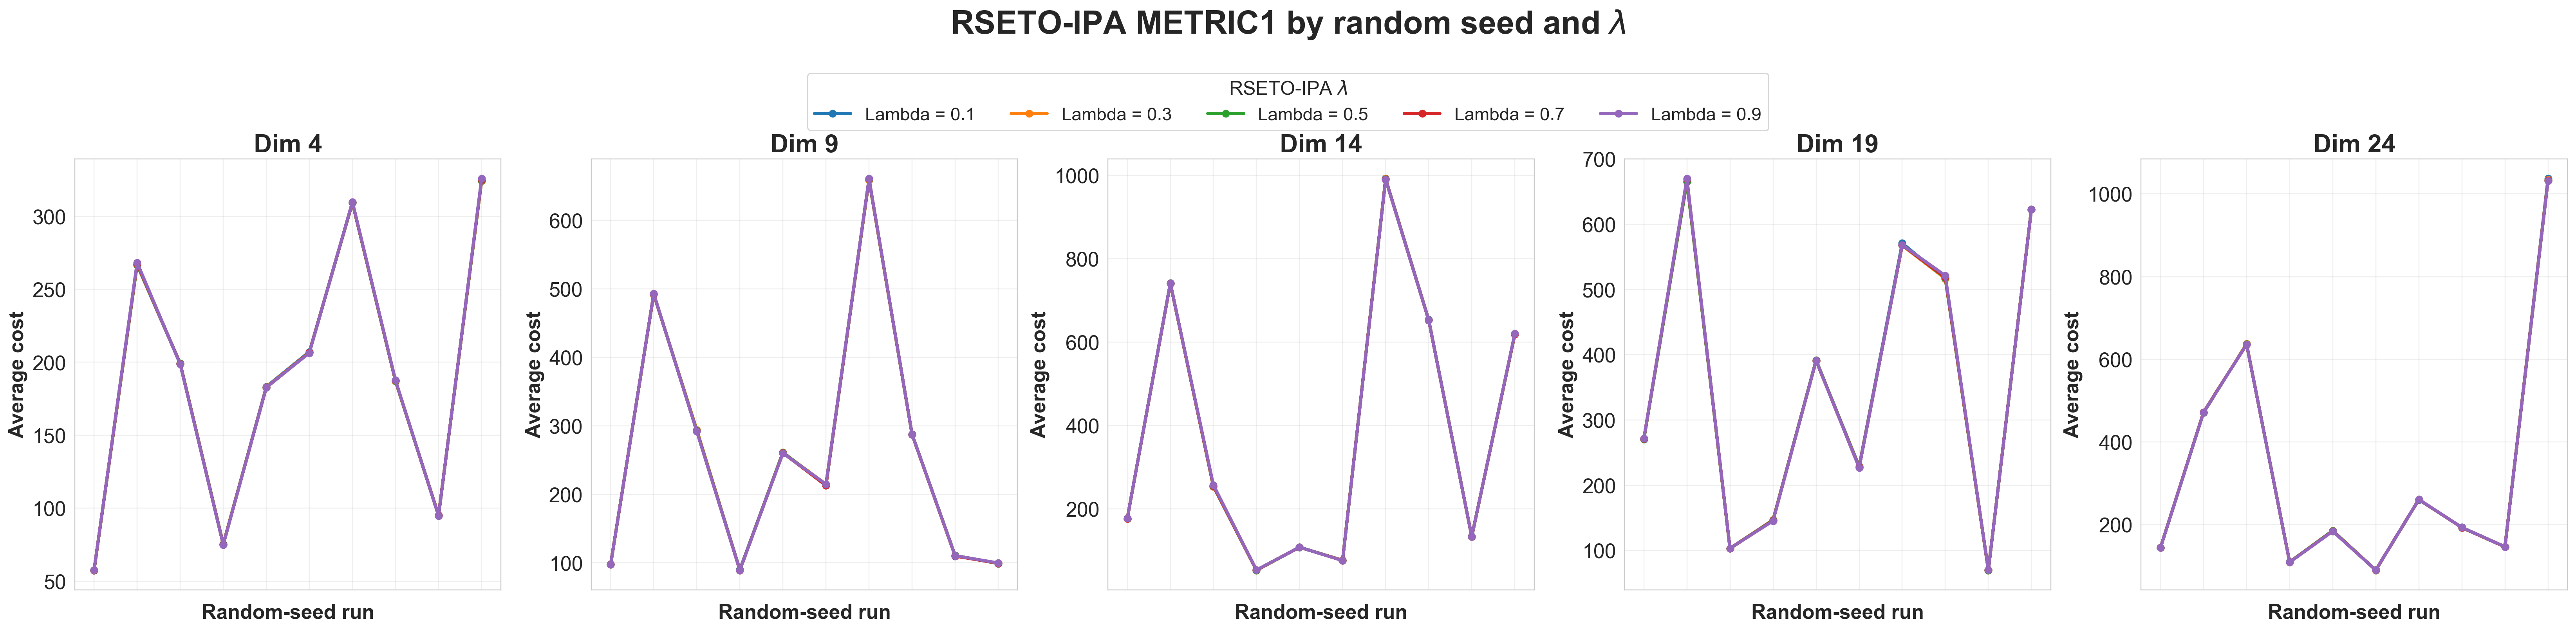

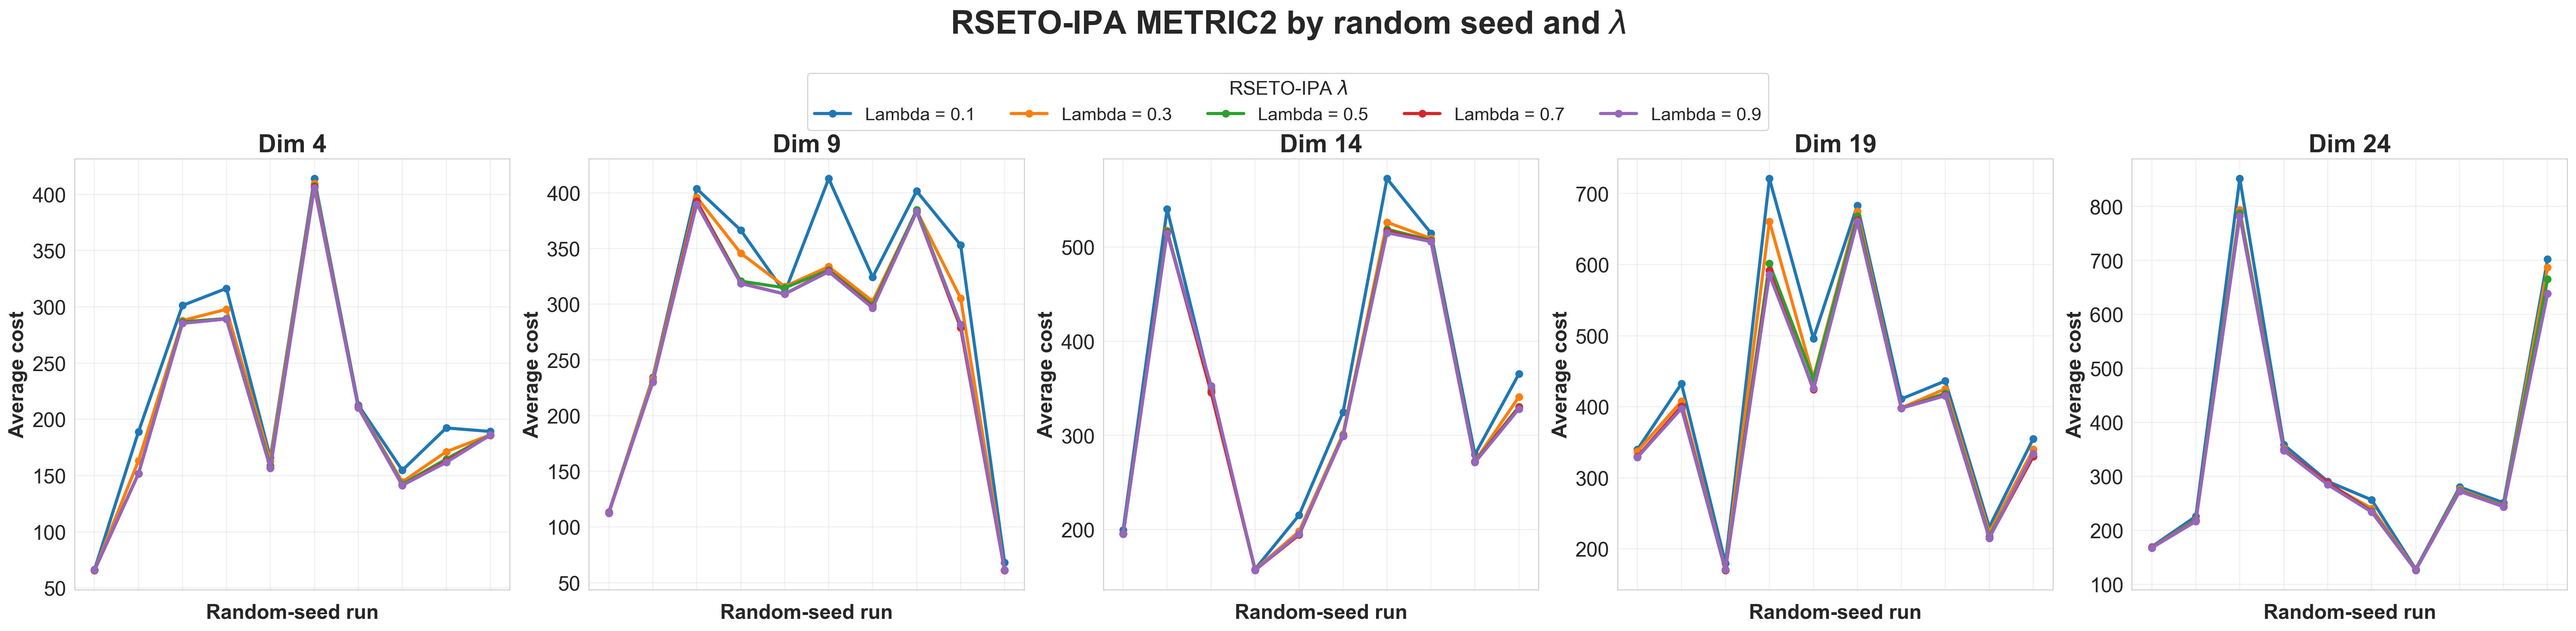

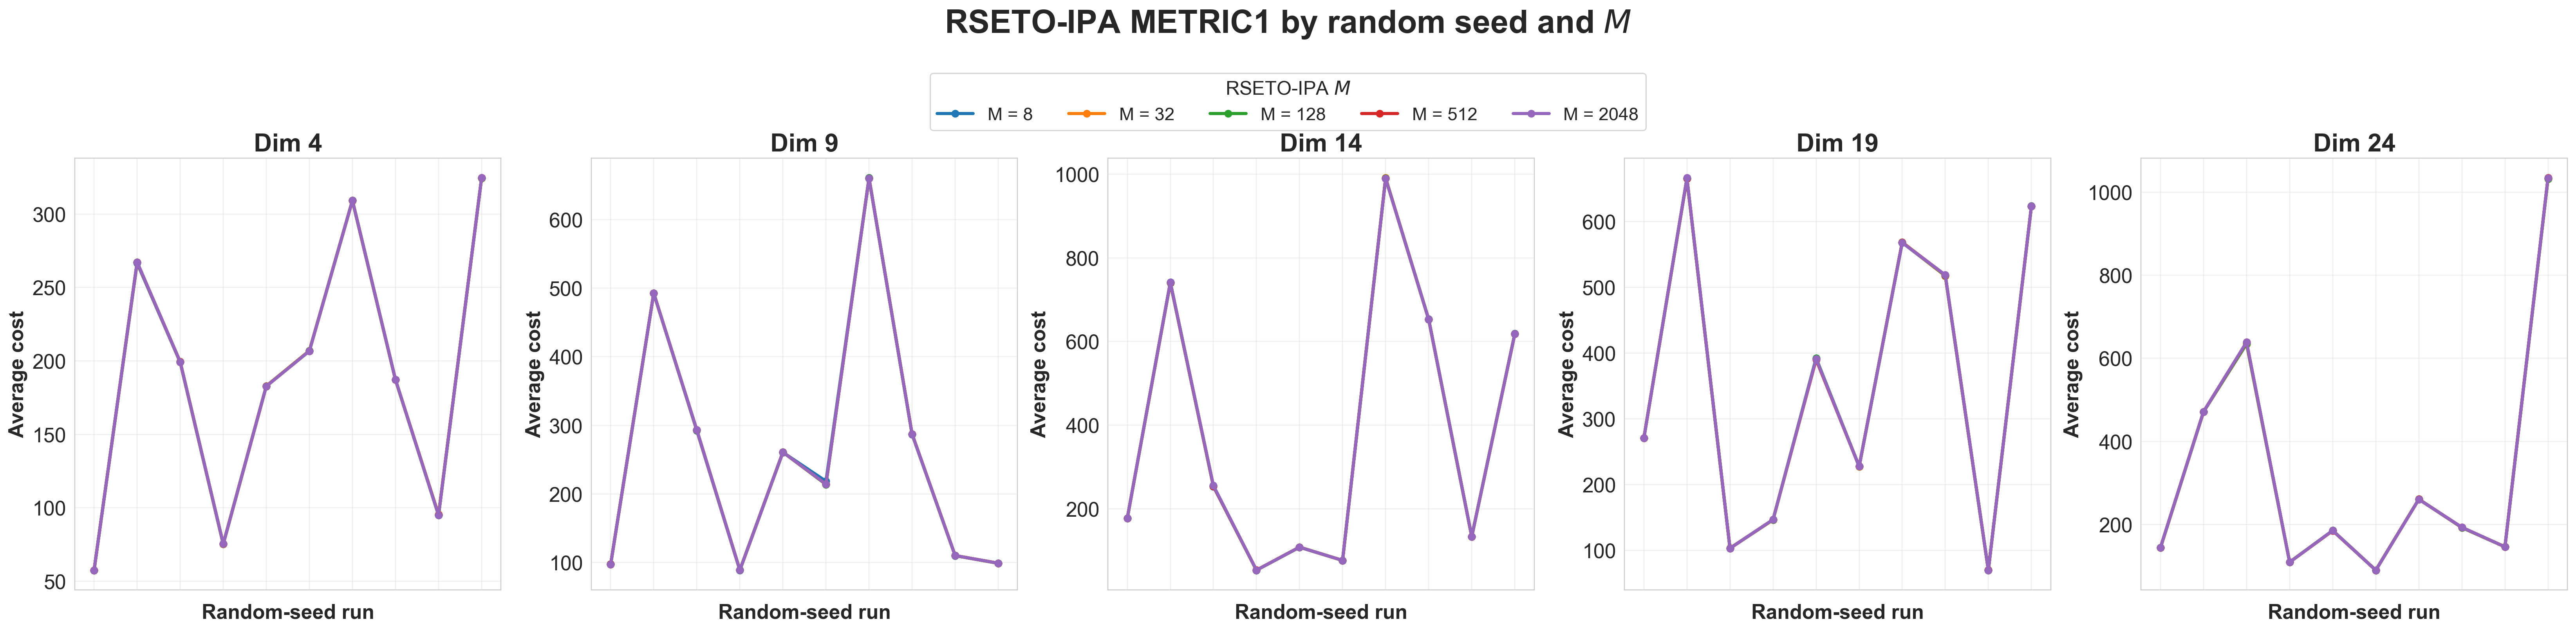

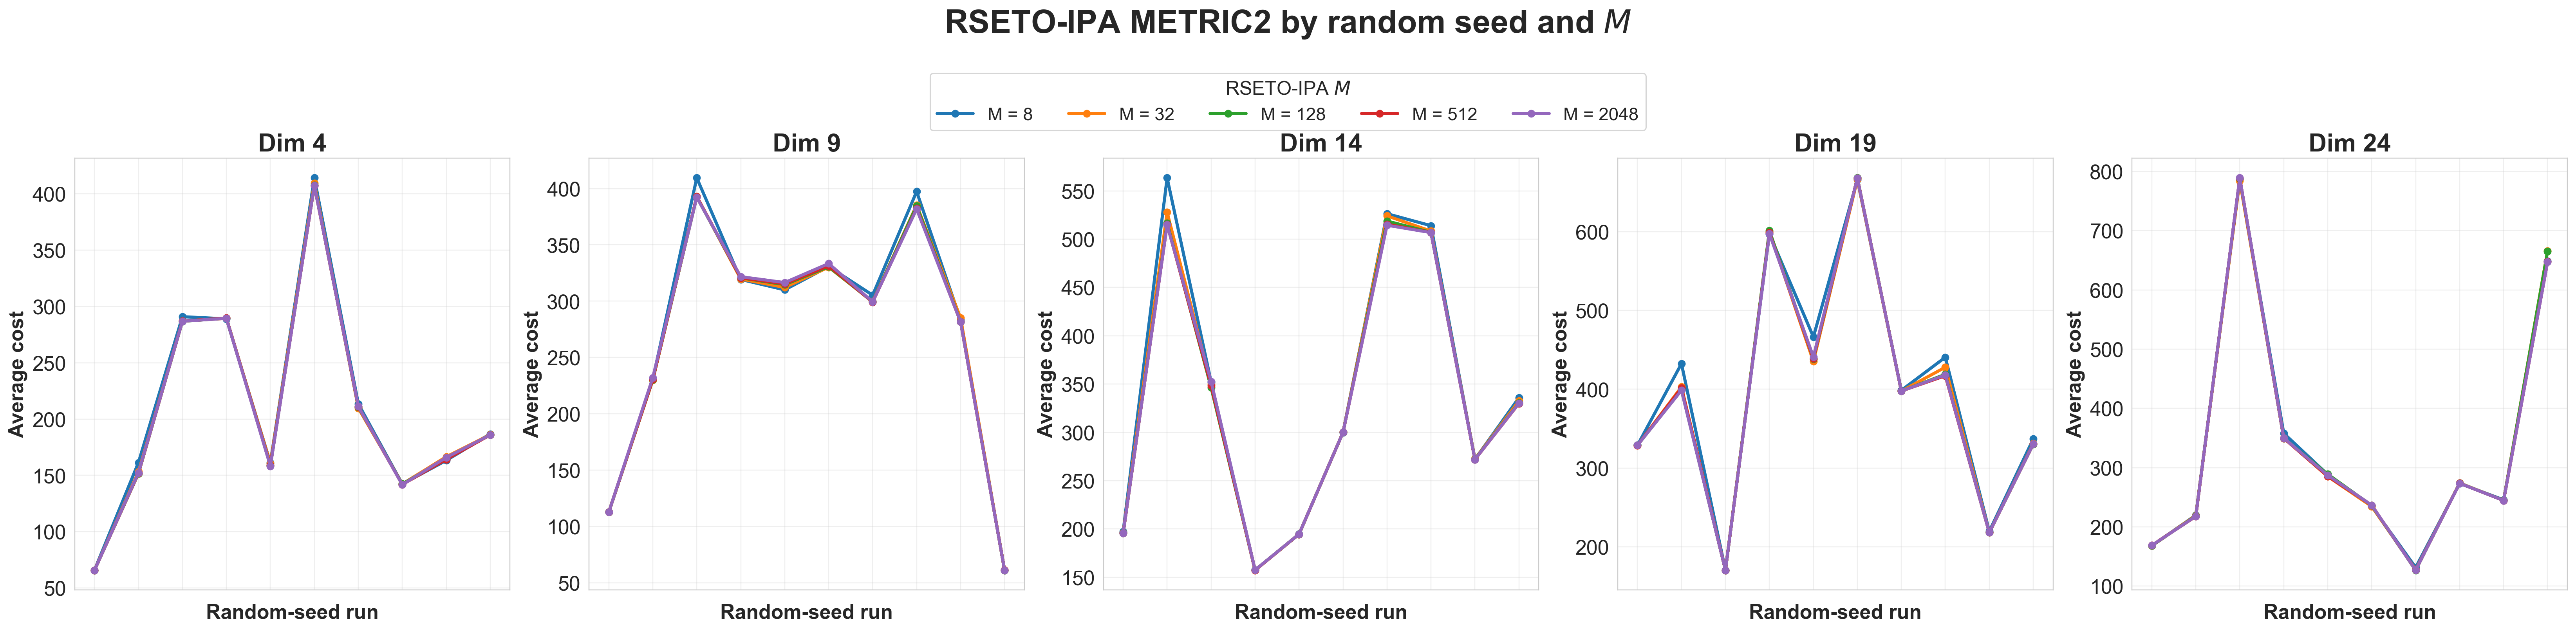

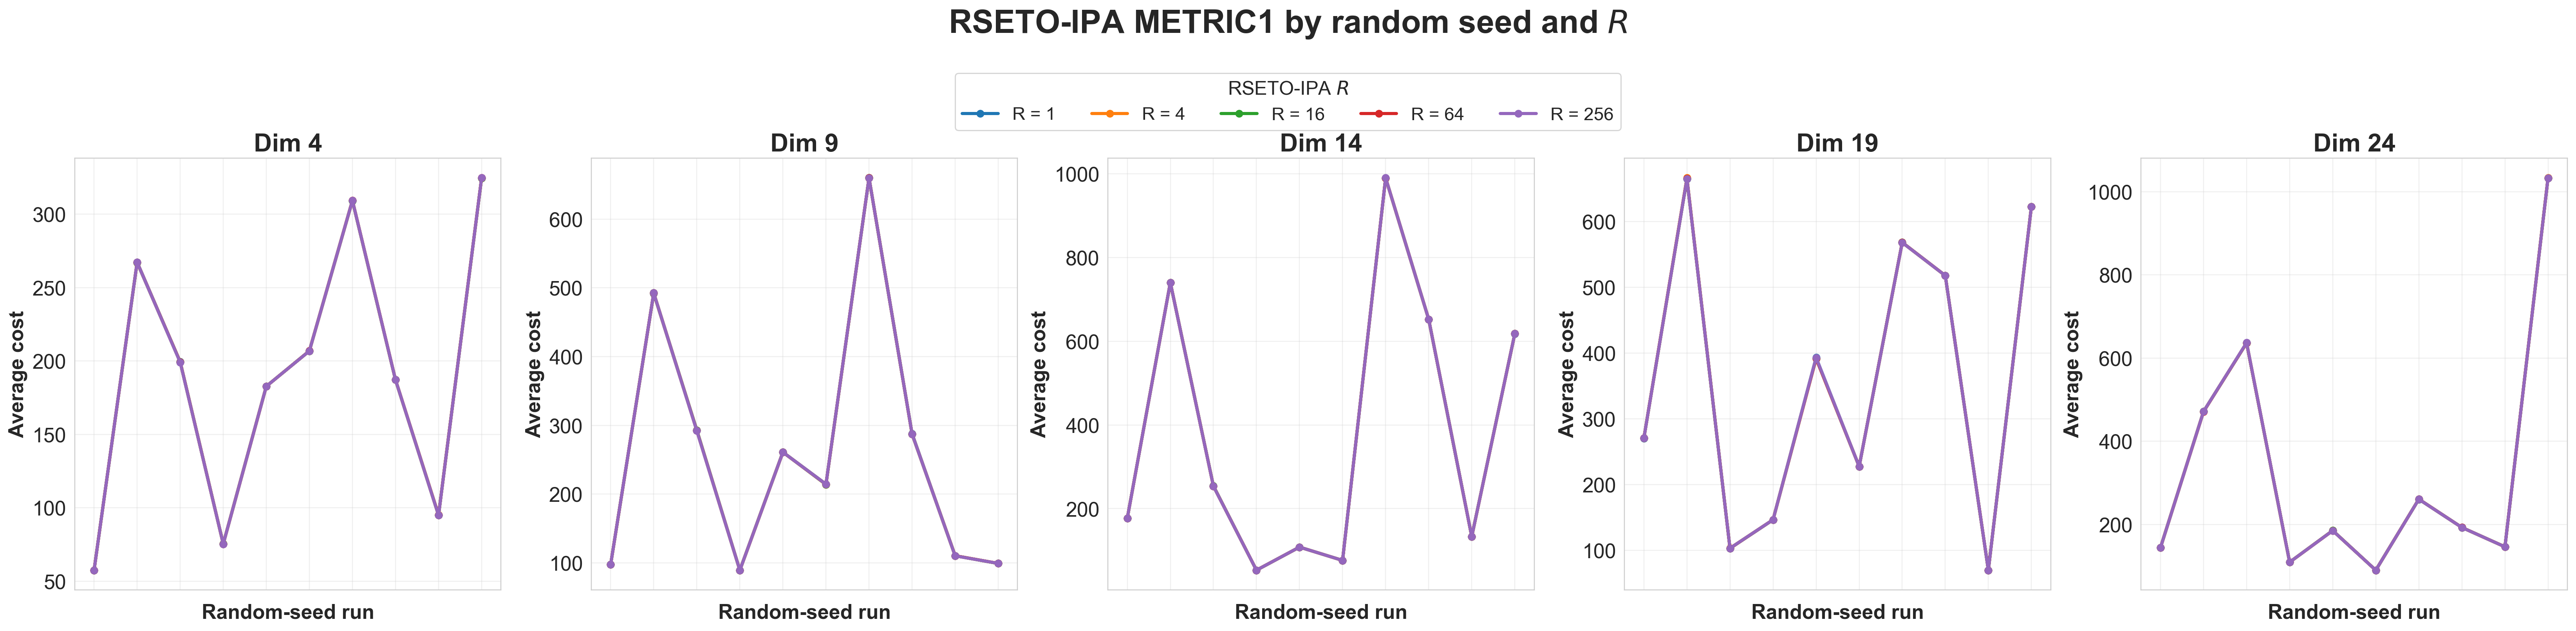

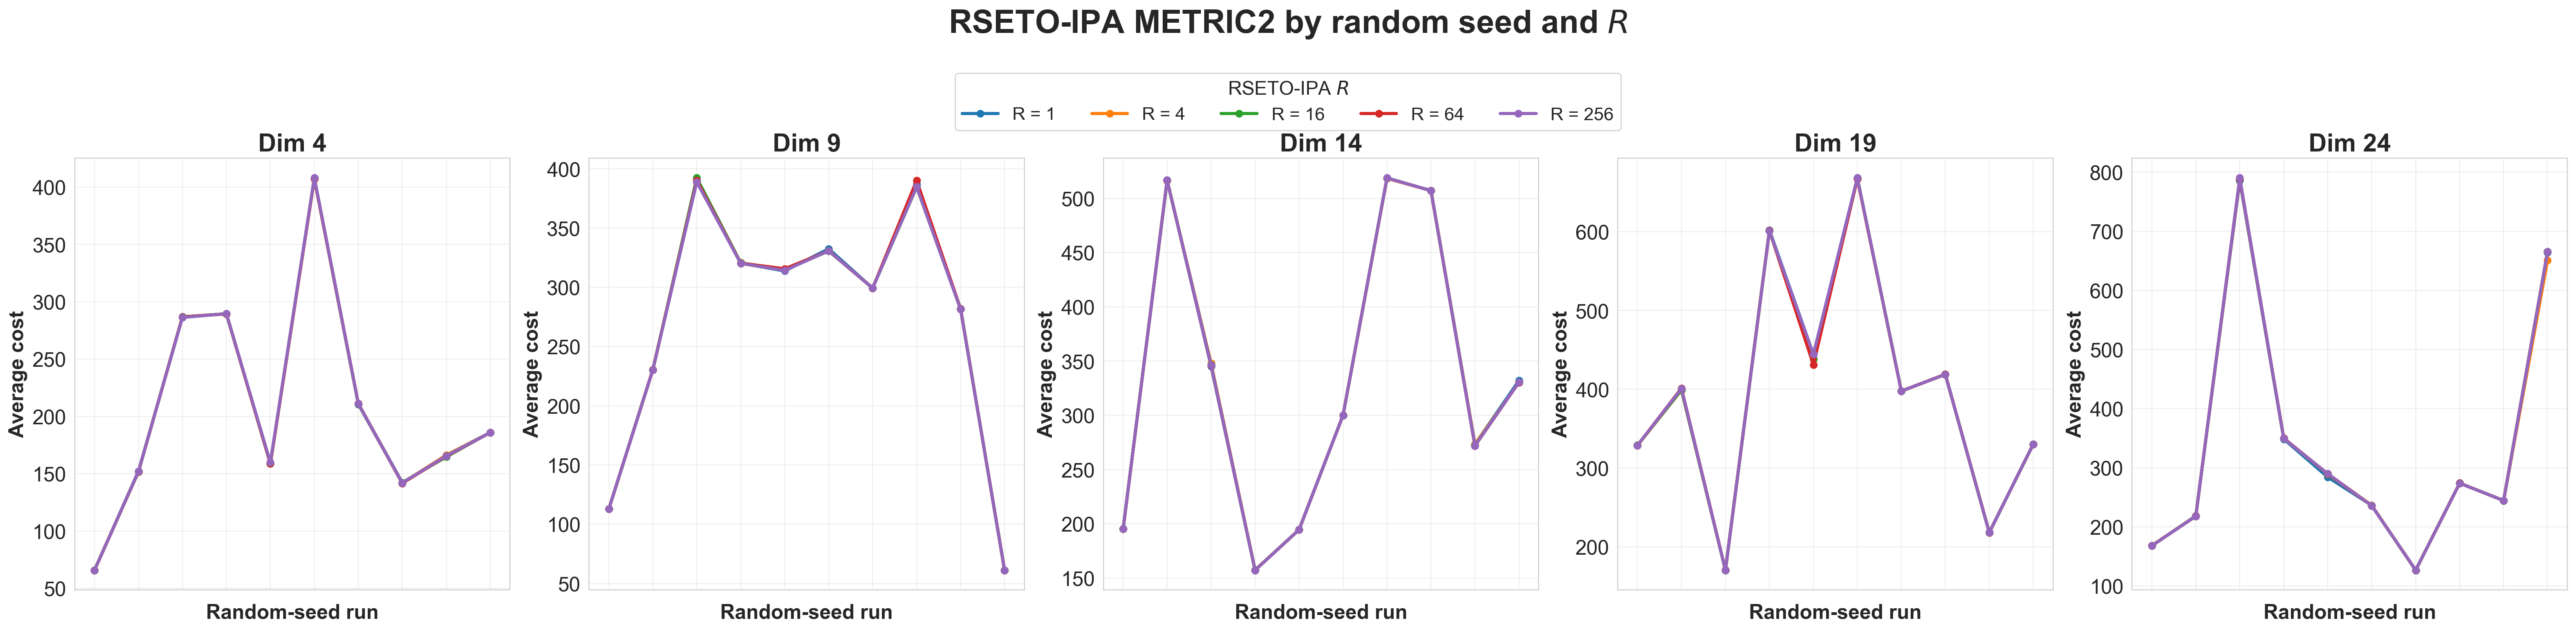

In [ ]:
def plot_parameter_profiles_by_seed(sweep, metric, save=True):
    if sweep not in {"lambda", "m", "simulation_num"}:
        raise ValueError("Seed-profile plots are requested only for lambda, M, and simulation number.")
    selected = sensitivity_results[sensitivity_results["sweep"] == sweep]
    parameter_values = SWEEP_INFO[sweep]["values"]
    symbol = SWEEP_INFO[sweep]["symbol"]
    seed_positions = np.arange(len(SEEDS))
    colors = sns.color_palette("tab10", n_colors=len(parameter_values))

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, len(DIMS), figsize=(30, 6.5), dpi=220, sharey=False)
    for axis, dim_value in zip(axes, DIMS):
        dim_data = selected[selected["dim"] == dim_value]
        for color, parameter_value in zip(colors, parameter_values):
            values = (
                dim_data[np.isclose(dim_data["parameter"], parameter_value)]
                .set_index("random_state")
                .reindex(SEEDS)[metric]
            )
            if values.isna().any():
                raise RuntimeError(f"Missing {sweep}/{metric}/dim={dim_value}/value={parameter_value} seed result.")
            label = parameter_column_name(sweep, parameter_value).replace(" ", " = ")
            axis.plot(seed_positions, values.to_numpy(dtype=float), color=color, linewidth=2.6, marker="o", markersize=5.5, label=label)
        axis.set_title(f"Dim {dim_value}", fontsize=21, fontweight="bold")
        axis.set_xticks(seed_positions)
        axis.set_xticklabels([])
        axis.set_xlabel("Random-seed run", fontsize=17, fontweight="bold")
        axis.set_ylabel("Average cost", fontsize=17, fontweight="bold")
        axis.tick_params(axis="y", labelsize=17)
        axis.tick_params(axis="x", length=4)
        axis.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=f"RSETO-IPA {symbol}", fontsize=15, title_fontsize=16, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=len(parameter_values), frameon=True)
    fig.suptitle(f"RSETO-IPA {metric.upper()} by random seed and {symbol}", fontsize=27, fontweight="bold", y=1.12)
    fig.tight_layout()
    if save:
        output_stem = SUMMARY_OUTPUT / f"{sweep}_{metric}_rseto_ipa_by_seed"
        fig.savefig(output_stem.with_suffix(".png"), dpi=300, bbox_inches="tight")
        fig.savefig(output_stem.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()
    return fig

seed_profile_figures = {}
for sweep_name in ["lambda", "m", "simulation_num"]:
    for metric_name in ["metric1", "metric2"]:
        seed_profile_figures[(sweep_name, metric_name)] = plot_parameter_profiles_by_seed(sweep_name, metric_name)


### Export all seed-level hyperparameter results

This export reads every individual metric NPY, validates it against `detail.csv`, and saves both the complete seed-level data and the mean/LaTeX summaries.

In [ ]:
from export_synthetic_hyperparameter_results import export_results

HYPERPARAMETER_EXPORT_DIR = Path("analysis_outputs/synthetic_hyperparameter_latex_results")
export_manifest = export_results(ANALYSIS_ROOT, ETE_DETAIL_PATH, HYPERPARAMETER_EXPORT_DIR)

all_seed_results = pd.read_csv(HYPERPARAMETER_EXPORT_DIR / "raw/all_hyperparameter_seed_results.csv")
gendfl_spline_all = pd.read_csv(HYPERPARAMETER_EXPORT_DIR / "raw/gendfl_spline_all_sweeps.csv")
spline_qfr_all = pd.read_csv(HYPERPARAMETER_EXPORT_DIR / "raw/spline_qfr_all_sweeps.csv")
rseto_ipa_all = pd.read_csv(HYPERPARAMETER_EXPORT_DIR / "raw/rseto_ipa_sweep_seed_results.csv")

print(export_manifest["row_counts"])
display(all_seed_results.head())
display(gendfl_spline_all.head())
display(spline_qfr_all.head())
display(rseto_ipa_all.head())